# Geotag Bottom Pictures
### GoPro Timelapse · GNSS Synchronisation · EXIF Geotagging

This notebook assigns GPS coordinates to photos collected during a seabed survey.
The camera (GoPro or similar) shoots a **timelapse** while a **GNSS receiver** records
a track in `.gpx` format. Because the two devices have independent clocks, the
notebook uses one **reference photo** — taken while the GNSS screen is visible —
to calculate and apply a time offset between the camera and the GNSS.

---

## What this notebook does

| Step | What happens |
|------|-------------|
| 1 | Install libraries and connect Google Drive |
| 2 | Load the geotagging functions |
| 3 | Set the paths to your input data |
| 4 | Load the photos and the GNSS track |
| 5 | Display the reference photo |
| 6 | Enter the GNSS time and synchronise the clocks |
| 7 | Match photos to the GNSS track |
| 8 | Write GPS coordinates into the photo EXIF metadata |
| 9 | Export photo positions as GeoJSON |
| 10 | Display the photo points on an interactive map |

## What you need before you start

- A folder of **GoPro timelapse photos** (`.JPG`).
- One or more **GPX files** recorded by a GNSS receiver during the survey.
- One **reference photo** that clearly shows the GNSS receiver screen
  (date and time must be readable).
- The geotagging script **`photo_gpx_geotagging.py`** in the `scripts/`
  subfolder of your project folder on Google Drive.

## How the clock synchronisation works

```
TIME_OFFSET = GNSS time shown in reference photo
            − EXIF timestamp of the same reference photo
```

This offset (which can be positive or negative) is then added to every photo
timestamp. Corrected timestamps are matched to the nearest GNSS position.

## Coordinate conventions

- GPX files use **WGS 84** geographic coordinates (EPSG:4326).
- Coordinates are stored as decimal degrees (longitude, latitude).
- GeoJSON output follows the standard order: `[longitude, latitude, altitude]`.
- Altitude is written as a constant value for all photos (default `0.0 m`).

---

> **New to Colab?**  Run cells one at a time using the ▶ button on the left,
> or press **Shift + Enter**. Cells marked **✏️ EDIT HERE** require you to
> change a value before running.


## Step 1 · Install libraries and connect Google Drive

This cell installs the required Python libraries, mounts Google Drive,
and registers the `scripts/` folder so that the geotagging module can
be imported in the next step.

> **✏️ EDIT HERE** — update `PROJECT_DIR` to match your project location.


In [1]:
# =============================================================================
# Step 1 · Install libraries and connect Google Drive
# =============================================================================

!pip install -q gpxpy piexif pillow pandas matplotlib folium

from google.colab import drive
from pathlib import Path
import sys

drive.mount("/content/drive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.5 MB/s eta 0:00:00
Mounted at /content/drive


In [2]:
# ─── ✏️ EDIT HERE ────────────────────────────────────────────────────────────
# Set this to the folder on Google Drive that contains the scripts/ subfolder.
PROJECT_DIR = Path(
    "/content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat"
)
# ─────────────────────────────────────────────────────────────────────────────

SCRIPTS_DIR = PROJECT_DIR / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

print(f"✅ Project folder : {PROJECT_DIR}")
print(f"   Scripts folder : {SCRIPTS_DIR}")


✅ Project folder : /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat
   Scripts folder : /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/scripts


## Step 2 · Load the geotagging functions

This cell imports all the processing functions from `photo_gpx_geotagging.py`.

`importlib.reload()` is included so that if you edit the script and re-run
this cell, Python will pick up the latest version automatically.


In [3]:
# =============================================================================
# Step 2 · Load the geotagging functions
# =============================================================================

import importlib
import photo_gpx_geotagging
importlib.reload(photo_gpx_geotagging)

from photo_gpx_geotagging import (
    find_photos,
    read_gpx_tracks,
    display_photo,
    parse_user_datetime,
    calculate_time_offset,
    build_photo_time_table,
    match_photos_to_gpx,
    write_matched_photo_exif,
    export_photo_points_geojson,
    export_processing_summary,
    plot_matches,
    print_match_report,
)

print("✅ Geotagging functions loaded.")


✅ Geotagging functions loaded.


## Step 3 · Set the paths to your input data

You need to provide three paths:

1. **`PHOTO_FOLDER`** — the folder containing the GoPro timelapse photos.
2. **`GPX_FILES`** — one or more GPX files recorded during the same survey.
   If you have multiple GPX files (e.g. one per transect), list them all.
3. **`REFERENCE_PHOTO`** — the photo showing the GNSS screen with a readable date and time.

> **✏️ EDIT HERE** — replace all three paths with your own.


In [4]:
# =============================================================================
# Step 3 · Set the paths to your input data
# =============================================================================

# ─── ✏️ EDIT HERE ────────────────────────────────────────────────────────────

# Folder containing the GoPro timelapse photos.
PHOTO_FOLDER = Path(
    "/content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/Timelapse"
)

# One or more GPX files (add more items to the list if needed).
GPX_FILES = [
    "/content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/GNSS/SiteX_SurveyY.gpx",
]

# Reference photo showing the GNSS receiver screen.
REFERENCE_PHOTO = Path(
    "/content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/GNSS/GOPR7544.JPG"
)

# ─────────────────────────────────────────────────────────────────────────────

print("Input data paths")
print("-" * 40)
print(f"  Photo folder    : {PHOTO_FOLDER}")
print("  GPX files:")
for gpx in GPX_FILES:
    print(f"    - {gpx}")
print(f"  Reference photo : {REFERENCE_PHOTO}")


Input data paths
----------------------------------------
  Photo folder    : /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/Timelapse
  GPX files:
    - /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/GNSS/SiteX_SurveyY.gpx
  Reference photo : /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/GNSS/GOPR7544.JPG


## Step 4 · Load the photos and the GNSS track

This cell finds all `.jpg` / `.jpeg` images in the photo folder and
reads the GPX track into a table of timestamped positions.

Check the output to confirm that the expected number of photos and
GNSS points have been loaded.


In [5]:
# =============================================================================
# Step 4 · Load the photos and the GNSS track
# =============================================================================

# Find all photos in the photo folder.
# recursive=True also searches any subfolders.
PHOTOS = find_photos(
    photo_folder=PHOTO_FOLDER,
    recursive=True,
)

# Read the GPX file(s) into a timestamped position table.
GPX_TRACK = read_gpx_tracks(GPX_FILES)

print("Loaded input data")
print("-" * 40)
print(f"  Photos found       : {len(PHOTOS)}")
print(f"  GPX points loaded  : {len(GPX_TRACK)}")
print()
print("First rows of GNSS track:")
GPX_TRACK.head()


Photo folder summary
--------------------
Photo folder: /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/Timelapse
Photos found: 593
GPX input summary
-----------------
GPX files provided: 1
- /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/GNSS/SiteX_SurveyY.gpx
GPX track summary
-----------------
GPX files read:  1
GNSS points:     1477
Start time UTC:  2026-06-21 13:46:24+00:00
End time UTC:    2026-06-21 14:11:02+00:00
Latitude range:  44.161465 to 44.162116
Longitude range: 8.334841 to 8.336715
Loaded input data
----------------------------------------
  Photos found       : 593
  GPX points loaded  : 1477

First rows of GNSS track:


,time,latitude,longitude,gpx_elevation,source_gpx,track_index,segment_index,point_index
0,2026-06-21 13:46:24+00:00,44.161841,8.334848,7.7,SiteX_SurveyY.gpx,0,0,0
1,2026-06-21 13:46:25+00:00,44.161840,8.334850,7.5,SiteX_SurveyY.gpx,0,0,1
2,2026-06-21 13:46:26+00:00,44.161840,8.334851,7.0,SiteX_SurveyY.gpx,0,0,2
3,2026-06-21 13:46:27+00:00,44.161838,8.334846,6.7,SiteX_SurveyY.gpx,0,0,3
4,2026-06-21 13:46:28+00:00,44.161831,8.334846,6.7,SiteX_SurveyY.gpx,0,0,4


## Step 5 · Display the reference photo

This cell shows the reference photo you selected in Step 3.

The photo should show the GNSS receiver screen with a clearly readable
date and time. You will type that date and time in the next step.


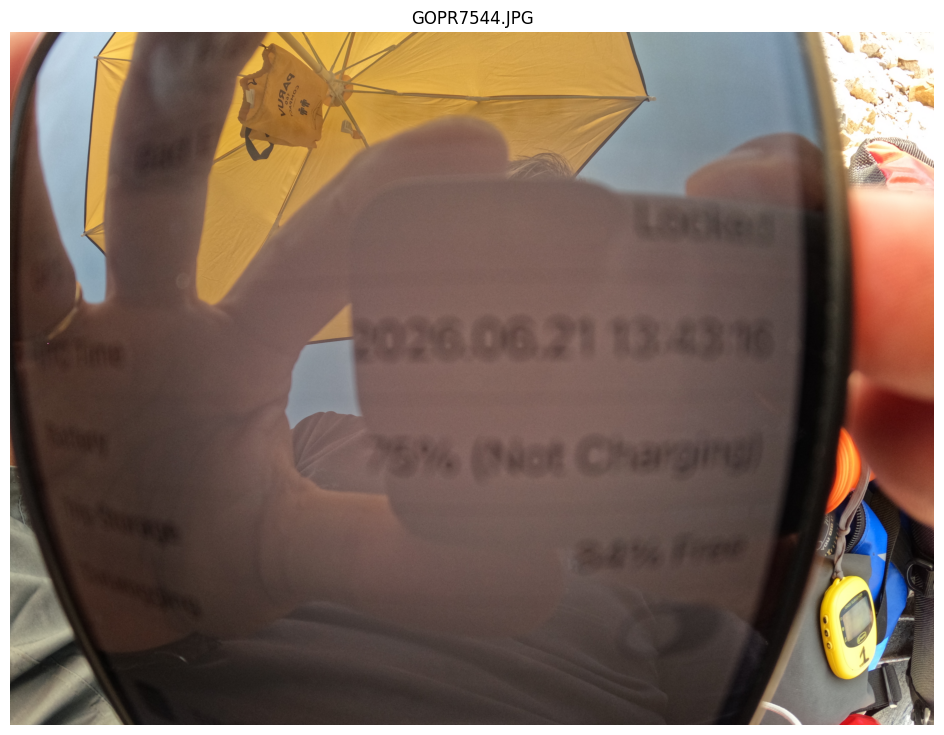

In [6]:
# =============================================================================
# Step 5 · Display the reference photo
# =============================================================================

display_photo(
    photo_path=REFERENCE_PHOTO,
    figsize=(14, 9),
)


## Step 6 · Enter the GNSS time and synchronise the clocks

Read the date and time shown on the GNSS receiver in the reference photo
and type it below.

Use this format exactly: `YYYY-MM-DD HH:MM:SS`

**Example:** `2026-06-21 13:43:16`

The notebook will:
1. Extract the EXIF timestamp from the same photo (set by the camera clock).
2. Calculate the time offset: `GNSS time − camera EXIF time`.
3. Add that offset to every photo timestamp.

The result is a corrected timestamp for each photo that can be matched
to the GNSS track.

> **✏️ EDIT HERE** — replace the example time with the one shown on the
> GNSS receiver in your reference photo.


In [7]:
# =============================================================================
# Step 6 · Synchronise the GoPro clock with the GNSS clock
# =============================================================================

# ─── ✏️ EDIT HERE ────────────────────────────────────────────────────────────
# Type the date and time visible on the GNSS receiver in the reference photo.
# Format: YYYY-MM-DD HH:MM:SS
GNSS_REFERENCE_TIME_STRING = "2026-06-21 13:43:16"
# ─────────────────────────────────────────────────────────────────────────────

# Convert the typed string to a Python datetime object.
GNSS_REFERENCE_TIME = parse_user_datetime(GNSS_REFERENCE_TIME_STRING)

# Calculate the time offset between the GoPro and the GNSS receiver.
TIME_SYNC_INFO = calculate_time_offset(
    reference_photo=REFERENCE_PHOTO,
    gnss_reference_time=GNSS_REFERENCE_TIME,
)

CAMERA_REFERENCE_TIME = TIME_SYNC_INFO["camera_reference_time"]
TIME_OFFSET           = TIME_SYNC_INFO["time_offset"]

# Apply the time offset to all photos to produce corrected timestamps.
PHOTO_TIMES = build_photo_time_table(
    photos=PHOTOS,
    time_offset=TIME_OFFSET,
)

print("Clock synchronisation")
print("-" * 40)
print(f"  Camera EXIF time   : {CAMERA_REFERENCE_TIME}")
print(f"  GNSS reference time: {GNSS_REFERENCE_TIME}")
print(f"  Time offset        : {TIME_OFFSET}")
print(f"  Offset in seconds  : {TIME_OFFSET.total_seconds():.0f} s")
print()
print("Photo timestamp table (first rows):")
PHOTO_TIMES.head()


Camera-GNSS time synchronization
--------------------------------
Reference photo:       GOPR7544.JPG
Camera EXIF time:      2026-06-21 15:43:16
GNSS reference time:   2026-06-21 13:43:16
Time offset:           -1 day, 22:00:00
Time offset seconds:   -7200
Time offset hours:     -2.000
Photo timestamp summary
-----------------------
Photos processed:      593
Valid EXIF times:      593
Invalid EXIF times:    0
First corrected time:  2026-06-21 13:55:28+00:00
Last corrected time:   2026-06-21 14:05:21+00:00
Clock synchronisation
----------------------------------------
  Camera EXIF time   : 2026-06-21 15:43:16
  GNSS reference time: 2026-06-21 13:43:16
  Time offset        : -1 day, 22:00:00
  Offset in seconds  : -7200 s

Photo timestamp table (first rows):


,photo_path,photo_name,camera_time,corrected_gnss_time,time_status,time_error_message
0,/content/drive/Othercomputers/My Mac/Documents...,G0027547.JPG,2026-06-21 15:55:28,2026-06-21 13:55:28+00:00,ok,None
1,/content/drive/Othercomputers/My Mac/Documents...,G0027548.JPG,2026-06-21 15:55:29,2026-06-21 13:55:29+00:00,ok,None
2,/content/drive/Othercomputers/My Mac/Documents...,G0027549.JPG,2026-06-21 15:55:30,2026-06-21 13:55:30+00:00,ok,None
3,/content/drive/Othercomputers/My Mac/Documents...,G0027550.JPG,2026-06-21 15:55:31,2026-06-21 13:55:31+00:00,ok,None
4,/content/drive/Othercomputers/My Mac/Documents...,G0027551.JPG,2026-06-21 15:55:32,2026-06-21 13:55:32+00:00,ok,None


## Step 7 · Match photos to the GNSS track

Each corrected photo timestamp is paired with the closest point in the
GNSS track. A match is accepted only if the time difference is within
`MAX_DELTA_SECONDS`.

**Choosing `MAX_DELTA_SECONDS`:**

| GNSS logging interval | Suggested value |
|----------------------|-----------------|
| 1 second             | `1.0`           |
| 2 seconds            | `2.0`           |
| 5 seconds            | `5.0`           |

Use the smallest value that still matches most of your photos.
A diagnostic plot is shown at the end so you can check the results visually.

> **✏️ EDIT HERE** if the default values do not suit your survey.


Photo-GPX matching summary
--------------------------
Photos processed:       593
Accepted matches:       593
Flagged photos:         0
Max allowed delta:      1.0 s
Largest accepted delta: 0.000 s
Match report
------------
Total photos:     593
Accepted matches: 593
Flagged photos:   0

Accepted time deltas
--------------------
Mean: 0.000 s
Max:  0.000 s


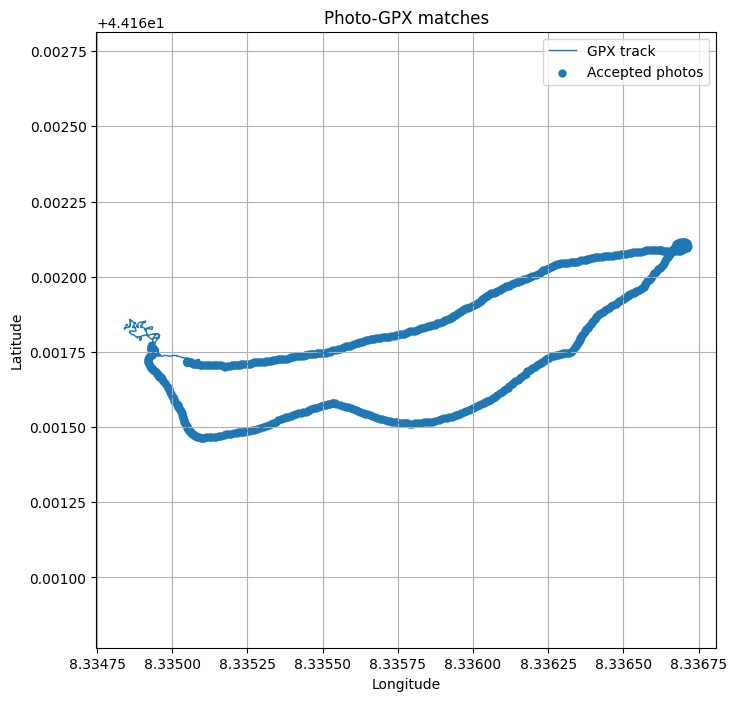


Match table (first rows):


,photo_path,photo_name,camera_time,corrected_gnss_time,time_status,time_error_message,matched_gpx_time,latitude,longitude,gpx_elevation,source_gpx,track_index,segment_index,point_index,time_delta_seconds,absolute_time_delta_seconds,altitude,match_status
0,/content/drive/Othercomputers/My Mac/Documents...,G0027547.JPG,2026-06-21 15:55:28,2026-06-21 13:55:28+00:00,ok,None,2026-06-21 13:55:28+00:00,44.161755,8.334936,0.4,SiteX_SurveyY.gpx,0,0,543,0.0,0.0,0.0,ok
1,/content/drive/Othercomputers/My Mac/Documents...,G0027548.JPG,2026-06-21 15:55:29,2026-06-21 13:55:29+00:00,ok,None,2026-06-21 13:55:29+00:00,44.161755,8.334938,0.4,SiteX_SurveyY.gpx,0,0,544,0.0,0.0,0.0,ok
2,/content/drive/Othercomputers/My Mac/Documents...,G0027549.JPG,2026-06-21 15:55:30,2026-06-21 13:55:30+00:00,ok,None,2026-06-21 13:55:30+00:00,44.161755,8.334938,0.4,SiteX_SurveyY.gpx,0,0,545,0.0,0.0,0.0,ok
3,/content/drive/Othercomputers/My Mac/Documents...,G0027550.JPG,2026-06-21 15:55:31,2026-06-21 13:55:31+00:00,ok,None,2026-06-21 13:55:31+00:00,44.161756,8.334938,0.4,SiteX_SurveyY.gpx,0,0,546,0.0,0.0,0.0,ok
4,/content/drive/Othercomputers/My Mac/Documents...,G0027551.JPG,2026-06-21 15:55:32,2026-06-21 13:55:32+00:00,ok,None,2026-06-21 13:55:32+00:00,44.161756,8.334938,0.3,SiteX_SurveyY.gpx,0,0,547,0.0,0.0,0.0,ok


In [8]:
# =============================================================================
# Step 7 · Match photos to the GNSS track
# =============================================================================

# ─── ✏️ EDIT HERE if needed ──────────────────────────────────────────────────

# Maximum allowed time difference between a photo and a GNSS point (seconds).
MAX_DELTA_SECONDS = 1.0

# Constant altitude value written into the photo EXIF metadata.
# Set to 0.0 if you do not have altitude information.
OUTPUT_ALTITUDE = 0.0

# ─────────────────────────────────────────────────────────────────────────────

PHOTO_MATCHES = match_photos_to_gpx(
    photo_times=PHOTO_TIMES,
    gpx_track=GPX_TRACK,
    max_delta_seconds=MAX_DELTA_SECONDS,
    output_altitude=OUTPUT_ALTITUDE,
)

# Print a short summary: how many photos were matched, how many were rejected.
print_match_report(PHOTO_MATCHES)

# Plot the GPX track and the matched photo positions for a visual check.
plot_matches(
    photo_matches=PHOTO_MATCHES,
    gpx_track=GPX_TRACK,
    figsize=(8, 8),
)

print()
print("Match table (first rows):")
PHOTO_MATCHES.head()


## Step 8 · Write GPS coordinates into the photo EXIF metadata

This cell embeds the matched GNSS position into the EXIF metadata of each
accepted photo.

### Two output modes

**Option A — recommended:** the notebook creates geotagged *copies* in a new
folder called `geotagged_photos/`. The original photos in `Timelapse/` are not changed.

**Option B:** GPS coordinates are written directly into the original photos.
Use this only if you are sure you do not need to keep the originals unmodified.
To switch to Option B, comment out the `Option A` line and uncomment `Option B`.

> This step can take a few minutes when working with Google Drive files,
> especially with many large images.


In [ ]:
# =============================================================================
# Step 8 · Write GPS coordinates into the photo EXIF metadata
# =============================================================================

# ── Option A — recommended: write geotagged COPIES (original photos preserved)
GEOTAGGED_PHOTO_FOLDER = PHOTO_FOLDER.parent / "geotagged_photos"

# ── Option B: modify the ORIGINAL photos in place (use with caution!)
# To activate, comment out the line above and uncomment the line below:
# GEOTAGGED_PHOTO_FOLDER = None

# Write GPS EXIF tags for every accepted photo match.
GEOTAGGING_RESULTS = write_matched_photo_exif(
    photo_matches=PHOTO_MATCHES,
    altitude=OUTPUT_ALTITUDE,
    output_folder=GEOTAGGED_PHOTO_FOLDER,
    overwrite=True,
    progress_every=25,
)

print()
if GEOTAGGED_PHOTO_FOLDER:
    print(f"✅ Geotagged copies saved to: {GEOTAGGED_PHOTO_FOLDER}")
else:
    print("✅ Original photos updated in place.")

print()
print("Geotagging results (first rows):")
GEOTAGGING_RESULTS.head()


EXIF GPS writing
----------------
Accepted photos to write: 593
Altitude/Z value:         0.0
Mode:                     copies in /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/geotagged_photos
Processed 25 / 593
Processed 50 / 593
Processed 75 / 593
Processed 100 / 593
Processed 125 / 593
Processed 150 / 593
Processed 175 / 593
Processed 200 / 593
Processed 225 / 593
Processed 250 / 593
Processed 275 / 593
Processed 300 / 593
Processed 325 / 593
Processed 350 / 593
Processed 375 / 593
Processed 400 / 593
Processed 425 / 593
Processed 450 / 593
Processed 475 / 593
Processed 500 / 593
Processed 525 / 593
Processed 550 / 593
Processed 575 / 593
Processed 593 / 593

EXIF writing summary
--------------------
Written: 593
Failed:  0
Skipped: 0

✅ Geotagged copies saved to: /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/geotagged_photos

Geot

,photo_path,photo_name,camera_time,corrected_gnss_time,time_status,time_error_message,matched_gpx_time,latitude,longitude,gpx_elevation,...,track_index,segment_index,point_index,time_delta_seconds,absolute_time_delta_seconds,altitude,match_status,exif_output_path,exif_write_status,exif_write_error
0,/content/drive/Othercomputers/My Mac/Documents...,G0027547.JPG,2026-06-21 15:55:28,2026-06-21 13:55:28+00:00,ok,None,2026-06-21 13:55:28+00:00,44.161755,8.334936,0.4,...,0,0,543,0.0,0.0,0.0,ok,/content/drive/Othercomputers/My Mac/Documents...,written,None
1,/content/drive/Othercomputers/My Mac/Documents...,G0027548.JPG,2026-06-21 15:55:29,2026-06-21 13:55:29+00:00,ok,None,2026-06-21 13:55:29+00:00,44.161755,8.334938,0.4,...,0,0,544,0.0,0.0,0.0,ok,/content/drive/Othercomputers/My Mac/Documents...,written,None
2,/content/drive/Othercomputers/My Mac/Documents...,G0027549.JPG,2026-06-21 15:55:30,2026-06-21 13:55:30+00:00,ok,None,2026-06-21 13:55:30+00:00,44.161755,8.334938,0.4,...,0,0,545,0.0,0.0,0.0,ok,/content/drive/Othercomputers/My Mac/Documents...,written,None
3,/content/drive/Othercomputers/My Mac/Documents...,G0027550.JPG,2026-06-21 15:55:31,2026-06-21 13:55:31+00:00,ok,None,2026-06-21 13:55:31+00:00,44.161756,8.334938,0.4,...,0,0,546,0.0,0.0,0.0,ok,/content/drive/Othercomputers/My Mac/Documents...,written,None
4,/content/drive/Othercomputers/My Mac/Documents...,G0027551.JPG,2026-06-21 15:55:32,2026-06-21 13:55:32+00:00,ok,None,2026-06-21 13:55:32+00:00,44.161756,8.334938,0.3,...,0,0,547,0.0,0.0,0.0,ok,/content/drive/Othercomputers/My Mac/Documents...,written,None


## Step 9 · Export photo positions as GeoJSON

This cell saves the matched photo positions to a **GeoJSON** file.

GeoJSON is a standard format that can be opened in:
- **QGIS** or **ArcGIS** as a vector point layer
- **Google Earth** (via the KML import)
- Any web map or GIS tool that supports GeoJSON

Each point feature contains the photo name, GPS coordinates, timestamps,
and the time difference between the photo and the matched GNSS point.

Only photos with an accepted match (`match_status = "ok"`) are exported.


In [ ]:
# =============================================================================
# Step 9 · Export photo positions as GeoJSON
# =============================================================================

# The GeoJSON file is saved inside the geotagged photo folder.
PHOTO_POINTS_GEOJSON = GEOTAGGED_PHOTO_FOLDER / "photo_points.geojson"

PHOTO_POINTS_GEOJSON = export_photo_points_geojson(
    photo_matches=GEOTAGGING_RESULTS,
    output_geojson=PHOTO_POINTS_GEOJSON,
    only_ok=True,   # Only export photos with a valid match
)

print(f"✅ GeoJSON saved to: {PHOTO_POINTS_GEOJSON}")


GeoJSON exported
----------------
Output file: /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/geotagged_photos/photo_points.geojson
Features:    593
✅ GeoJSON saved to: /content/drive/Othercomputers/My Mac/Documents/Work_science/SEASTRONG/Tutorials/Ground_truthing_bathy_habitat/Example data/geotagged_photos/photo_points.geojson


## Step 10 · Display the photo points on an interactive map

This cell loads the GeoJSON file and shows all photo positions on an
interactive map inside the notebook.

**How to use the map:**
- Pan and zoom as in Google Maps.
- Click any point to see the photo name, GNSS timestamp, and time delta.
- Hover over a point to see a quick summary tooltip.

If the map is empty, check that Step 9 produced a non-empty GeoJSON file.


In [ ]:
# =============================================================================
# Step 10 · Display the photo points on an interactive map
# =============================================================================

import json
import folium

# Load the GeoJSON file written in the previous step.
with open(PHOTO_POINTS_GEOJSON, "r", encoding="utf-8") as f:
    photo_geojson = json.load(f)

features = photo_geojson["features"]

if len(features) == 0:
    raise ValueError(
        "The GeoJSON file contains no photo points.\n"
        "Check the match report in Step 7 — all photos may have been rejected."
    )

# GeoJSON coordinates are stored as [longitude, latitude, altitude].
coordinates = [feat["geometry"]["coordinates"] for feat in features]
lats = [c[1] for c in coordinates]
lons = [c[0] for c in coordinates]

# Centre the map on the average photo position.
photo_map = folium.Map(
    location=[sum(lats) / len(lats), sum(lons) / len(lons)],
    zoom_start=18,
    tiles="OpenStreetMap",
)

# Add the GeoJSON layer with hover tooltips.
folium.GeoJson(
    photo_geojson,
    name="Photo points",
    tooltip=folium.GeoJsonTooltip(
        fields=["photo_name", "matched_gpx_time", "absolute_time_delta_seconds"],
        aliases=["Photo", "GNSS time", "Time delta (s)"],
        localize=True,
    ),
).add_to(photo_map)

# Add clickable circle markers with a detailed popup.
for feat in features:
    lon, lat, *rest = feat["geometry"]["coordinates"]
    props = feat["properties"]
    altitude = rest[0] if rest else 0.0

    popup_html = (
        f"<b>{props.get('photo_name', '')}</b><br>"
        f"Latitude : {lat:.7f}<br>"
        f"Longitude: {lon:.7f}<br>"
        f"Altitude : {altitude} m<br>"
        f"GNSS time: {props.get('matched_gpx_time', '')}<br>"
        f"Time delta: {props.get('absolute_time_delta_seconds', '')} s"
    )

    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        color="#E91E63",
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=300),
    ).add_to(photo_map)

folium.LayerControl().add_to(photo_map)

print(f"Showing {len(features)} geotagged photo positions.")
photo_map


Showing 593 geotagged photo positions.
